# Demonstration of Fourier Transform, DFT, and FFT

In [5]:
## Resource:
## https://blog.yeshuanova.com/2019/04/fft_intro/


import numpy as np
import matplotlib.pyplot as plt
from scipy import pi
from scipy.fftpack import fft
from scipy.fftpack import ifft

%matplotlib inline

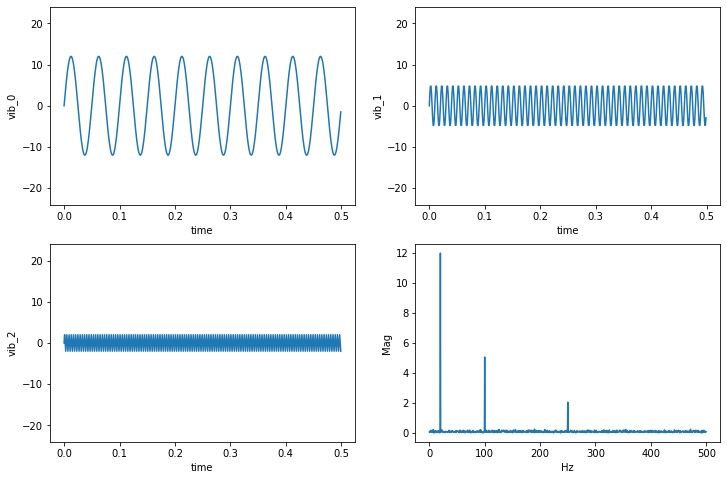

In [30]:
sample_num = 2000 # Sampling points
total_time = 2 # Sampling number
sampling_rate = sample_num / total_time # 取樣頻率

fs = [(20, 12), (100, 5), (250, 2)] # sin 波的頻率與振幅組合。 (Hz, Amp)
noise_mag = 2

time = np.linspace(0, total_time, sample_num, endpoint=False)

vib_data = [amp * np.sin(2*pi*hz*time) for hz, amp in fs]

max_time = int(sample_num / 4)

plt.figure(figsize=(12, 8))
# Show seperated signal
for idx, vib in enumerate(vib_data):
    plt.subplot(2, 2, idx+1)
    plt.plot(time[0:max_time], vib[0:max_time])
    plt.xlabel('time')
    plt.ylabel('vib_' + str(idx))
    plt.ylim((-24, 24))

vib = sum(vib_data) + np.random.normal(0, noise_mag, sample_num) # Add noise

plt.subplot(2, 2, 4)
#plt.plot(time[0:max_time], vib[0:max_time])
#plt.xlabel('time')
#plt.ylabel('vib(with noise)')
#plt.ylim((-24, 24))


fd = np.linspace(0.0, sampling_rate, int(sample_num), endpoint=False)

vib_fft = fft(vib)
mag = 2/sample_num * np.abs(vib_fft) # Magnitude

plt.plot(fd[0:int(sample_num/2)], mag[0:int(sample_num/2)])
plt.xlabel('Hz')
plt.ylabel('Mag')
plt.show()

(-24.0, 24.0)

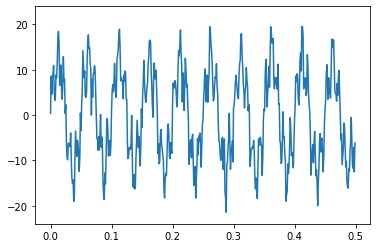

In [6]:
vib_re = np.real(ifft(vib_fft)) # Real part of complex number

plt.plot(time[0:max_time], vib_re[0:max_time])
plt.ylim((-24, 24))

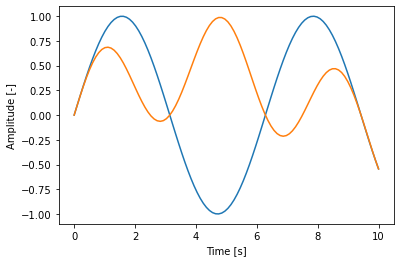

In [32]:
## A test about the shift of phase 
# g(t)exp{j * 2 * pi * f_0 * t} = G(f - f_0)
t = np.linspace(0, 10, 100)
f_0 = 10
g = np.sin(t)
g_new = g * np.exp(1j * 2 * np.pi * f_0 * t)

plt.figure()
plt.plot(t, g)
plt.plot(t, np.real(g_new))
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [-]')
plt.show()

Text(0, 0.5, 'Mag')

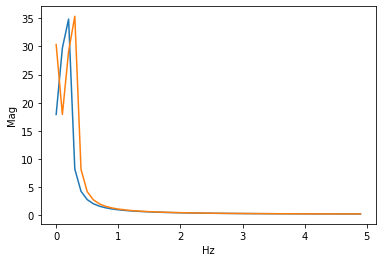

In [33]:
fd = np.linspace(0.0, 10, int(100), endpoint=False)

plt.plot(fd[0:int(100/2)], np.abs(fft(g)[0:int(100/2)]))
plt.plot(fd[0:int(100/2)], np.abs(fft(g_new)[0:int(100/2)]))
plt.xlabel('Hz')
plt.ylabel('Mag')